In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt

def scat(x, y, c,marker):
    return ax.scatter(x, y*100, c=c, ls='-', cmap=cmap, norm=norm, s=30, marker=marker
                     )
import pyccl as ccl
import sys
sys.path.append('../forecasts/')
import fisher_matrix_bao_SuEisenstein
sys.path.append('../survey_design/')
import _tracer_spectroscopic_efficiency
import _survey_design_telescope_metrics
import _surveys
import _survey_design_science_metrics

h=0.677
deltac=1.686
H0=100*h
c_ls=300*10**3
nlim=10000
n_s=0.968

cosmo = ccl.Cosmology(Omega_c=0.27, Omega_b=0.045, h=h, A_s=2.1e-9, n_s=n_s,transfer_function='boltzmann_camb')

In [2]:
import pickle
def save_pickle(dat, filename, **kwargs):
    file = open(filename,'wb')
    pickle.dump(dat, file)
    file.close()
def load(filename, **kwargs):
    with open(filename, 'rb') as fin:
        return pickle.load(fin, **kwargs)

In [3]:
path = '../survey_design/telescope_and_science_metrics/'

In [4]:
survey_design_dark = load(path + 'survey_design_Dark_lbg_only_bao.pkl')
survey_design_dark_qso = load(path + 'survey_design_Dark_qso_only_bao.pkl')
survey_design_dark_one_tracer = load(path + 'survey_design_Dark_lbg_only_onetracer_approach.pkl')

LBGu = 5180.838323353293
LBGg = 2555.0898203592815
LBGr = 497.0059880239521


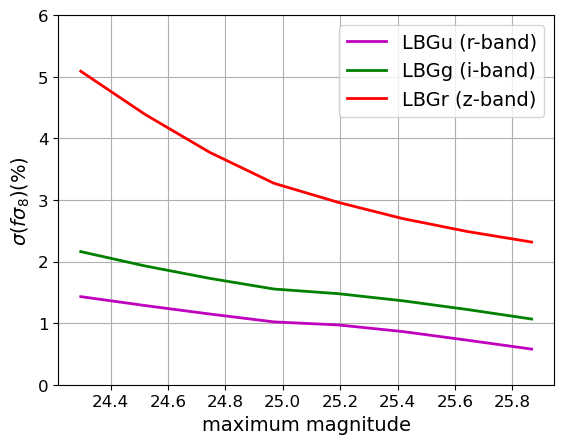

In [6]:
n=0
for k, tracer in enumerate(['LBGu', 'LBGg', 'LBGr']):
    
    survey = survey_design_dark
    i=3
    
    print(tracer, '=', survey['config_survey'][tracer+'_target_density'][i])

    mask_color = np.array(survey['config_survey']['tracers'])==tracer
   
    color = np.array(survey['config_survey']['color'])[mask_color][0]

    


    mask_index_tracer_in_survey = survey["config_survey"]['tracers'] == tracer
    x, y = survey['config_survey'][tracer+'_mag_centers'], 100*np.array(survey['per_tracer_forecasts'][tracer+'_sigma_rsd_eff'])
    plt.plot(x, y, '-', label = tracer+ f' ({survey["config_survey"]["limiting_mag_band"][k]}-band)',
                 color = color, lw=2,
                 marker='', )



plt.ylim(0, 6)
plt.grid()
#plt.yscale('log')
#plt.ylabel(r'$\sigma(f_{\rm NL})$', fontsize=15)
plt.xlabel(r'maximum magnitude', fontsize=14)
plt.ylabel(r'$\sigma(f\sigma_8) (\%)$', fontsize=14)
plt.tick_params(axis='both', labelsize=12)
plt.legend(fontsize=14, ncols=1, loc='upper right')
plt.savefig(f'../figures_for_paper/lbg_rsd.png', dpi = 200, bbox_inches='tight',)

LBGu  mag = 24.97

LBGu  mag = 25.64

LBGg  mag = 24.97

LBGg  mag = 25.64

LBGr  mag = 24.97

LBGr  mag = 25.64



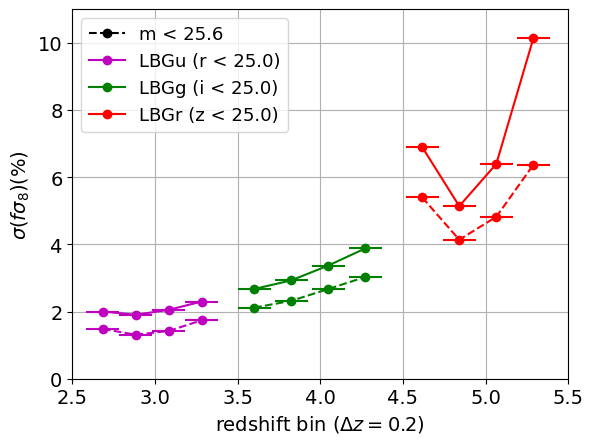

In [8]:
n=0
for k, tracer in enumerate(['LBGu', 'LBGg', 'LBGr']):

    survey = survey_design_dark 

    mask_color = np.array(survey['config_survey']['tracers'])==tracer
   
    color = np.array(survey['config_survey']['color'])[mask_color][0]
    
    mag_Str = np.array(survey['config_survey']['limiting_mag_band'])[mask_color][0]
    #print(survey['config_survey'][tracer+'_spec_density'][i])
    i=3

    max_mag = survey['config_survey'][tracer + '_mag_centers'][i]

    print(tracer, f' mag = {max_mag:.2F}')
    print()
    label = tracer + f' ({mag_Str} < {max_mag:.1f})'

    x, y = survey['per_tracer_forecasts'][tracer+'_list_zbin_rsd'][i], 100*np.array(survey['per_tracer_forecasts'][tracer+'_list_sigma_rsd'][i])
    plt.errorbar(np.array(x)[y < 15], np.array(y)[y < 15], xerr=0.1, label = label,
                 color = color, 
                 marker='o', fmt='-')


    i=6

    max_mag = survey['config_survey'][tracer + '_mag_centers'][i]

    print(tracer, f' mag = {max_mag:.2F}')
    print()
    label = tracer + f' ({mag_Str} < {max_mag:.1f})'

    x, y = survey['per_tracer_forecasts'][tracer+'_list_zbin_rsd'][i], 100*np.array(survey['per_tracer_forecasts'][tracer+'_list_sigma_rsd'][i])
    plt.errorbar(np.array(x)[y < 10], np.array(y)[y < 10], xerr=0.1,
                 color = color, 
                 marker='o', fmt='--')

plt.plot([], [], '--o', color = 'k', label = f'm < {max_mag:.1f}')

plt.ylim(0, 11)
plt.xlim(2.5, 5.5)
plt.ylabel(r'$\sigma(f\sigma_8) (\%)$', fontsize=14)
plt.xlabel(r'redshift bin ($\Delta z = 0.2)$', fontsize=14)
plt.tick_params(axis='both', labelsize=14)
plt.legend(fontsize=13, loc='upper left')
plt.grid()
plt.savefig(f'../figures_for_paper/lbg_rsd_redshift_bins.png', dpi = 200, bbox_inches='tight',)